#Task 1

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aldinwhyudii/student-depression-and-lifestyle-100k-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-depression-and-lifestyle-100k-data' dataset.
Path to dataset files: /kaggle/input/student-depression-and-lifestyle-100k-data


In [6]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory '{path}':")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Contents of the dataset directory '/kaggle/input/student-depression-and-lifestyle-100k-data':
/kaggle/input/student-depression-and-lifestyle-100k-data/student_lifestyle_100k.csv


In [7]:
import pandas as pd
import os

# Construct the full path to the correct CSV file
file_path = os.path.join(path, 'student_lifestyle_100k.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

print("DataFrame loaded successfully.")

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

# Print a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()

DataFrame loaded successfully.

First 5 rows of the DataFrame:
   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science  3.50             7.3          3.3   
1        1002   20    Male  Engineering  2.72             5.5          7.2   
2        1003   20    Male      Medical  3.01             5.4          2.3   
3        1004   21    Male  Engineering  3.63             8.1          2.0   
4        1005   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64


In [9]:
print("Unique values and counts for 'Gender' column:")
print(df['Gender'].value_counts())
print("\nUnique values and counts for 'Department' column:")
print(df['Department'].value_counts())

Unique values and counts for 'Gender' column:
Gender
Male      50120
Female    49880
Name: count, dtype: int64

Unique values and counts for 'Department' column:
Department
Science        20071
Engineering    20057
Arts           19998
Medical        19964
Business       19910
Name: count, dtype: int64


In [10]:
df['Gender'] = df['Gender'].astype('category')
df['Department'] = df['Department'].astype('category')
df = df.drop('Student_ID', axis=1)

print("Data cleaning steps completed.")
print("New DataFrame Info after cleaning:")
df.info()

Data cleaning steps completed.
New DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   Age                 100000 non-null  int64   
 1   Gender              100000 non-null  category
 2   Department          100000 non-null  category
 3   CGPA                100000 non-null  float64 
 4   Sleep_Duration      100000 non-null  float64 
 5   Study_Hours         100000 non-null  float64 
 6   Social_Media_Hours  100000 non-null  float64 
 7   Physical_Activity   100000 non-null  int64   
 8   Stress_Level        100000 non-null  int64   
 9   Depression          100000 non-null  bool    
dtypes: bool(1), category(2), float64(4), int64(3)
memory usage: 5.6 MB


In [11]:
print("First 5 rows of the cleaned DataFrame:")
print(df.head())

print("\nInfo of the cleaned DataFrame:")
df.info()

First 5 rows of the cleaned DataFrame:
   Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0   22  Female      Science  3.50             7.3          3.3   
1   20    Male  Engineering  2.72             5.5          7.2   
2   20    Male      Medical  3.01             5.4          2.3   
3   21    Male  Engineering  3.63             8.1          2.0   
4   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  

Info of the cleaned DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Col

We will start by seperating the features into X and the target variable y for Depressionion and split the data into testing and training sets to help aid with the Decision Tree classification

In [12]:
from sklearn.model_selection import train_test_split

# 1. Convert categorical columns ('Gender', 'Department') into numerical format using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Gender', 'Department'], drop_first=False)

print("DataFrame after one-hot encoding:")
print(df_encoded.head())
print("\nInfo of the encoded DataFrame:")
df_encoded.info()

# 2. Separate the features (X) and the target variable (y - 'Depression')
X = df_encoded.drop('Depression', axis=1)
y = df_encoded['Depression']

print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# 3. Split the X and y data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Data preprocessing for Decision Tree completed.")

DataFrame after one-hot encoding:
   Age  CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0   22  3.50             7.3          3.3                 3.4   
1   20  2.72             5.5          7.2                 6.0   
2   20  3.01             5.4          2.3                 1.8   
3   21  3.63             8.1          2.0                 4.6   
4   19  3.14             6.8          2.6                 4.3   

   Physical_Activity  Stress_Level  Depression  Gender_Female  Gender_Male  \
0                114             5       False           True        False   
1                142             2       False          False         True   
2                137             3       False          False         True   
3                130             3       False          False         True   
4                  4             6       False          False         True   

   Department_Arts  Department_Business  Department_Engineering  \
0            False                False

By importing sklearn training data we can take a look

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1 & 2. Instantiate a DecisionTreeClassifier object with default parameters
dtc = DecisionTreeClassifier(random_state=42)

# 3. Train the model using the .fit() method on X_train and y_train
print("Training Decision Tree Classifier...")
dtc.fit(X_train, y_train)
print("Decision Tree Classifier trained successfully.")

# 4. Make predictions on the test set X_test
y_pred = dtc.predict(X_test)

# 5 & 6. Calculate the accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 7. Print the calculated metrics
print("\nDecision Tree Classifier Performance Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Training Decision Tree Classifier...
Decision Tree Classifier trained successfully.

Decision Tree Classifier Performance Metrics:
Accuracy:  0.8171
Precision: 0.1568
Recall:    0.1885
F1-Score:  0.1712


Using the decision tree we can see the output  of our performance metrics where right now the model currently has an accuaracy of 81%, precision score of 15%, recall 18% and F1 of 17% which compared to our last homework was significantly better.

Impletening 3 different paramtters we will do depth of 3,  depth of 5 and depth of 10


Training Decision Tree Classifier with max_depth=3...
Decision Tree Classifier trained successfully.


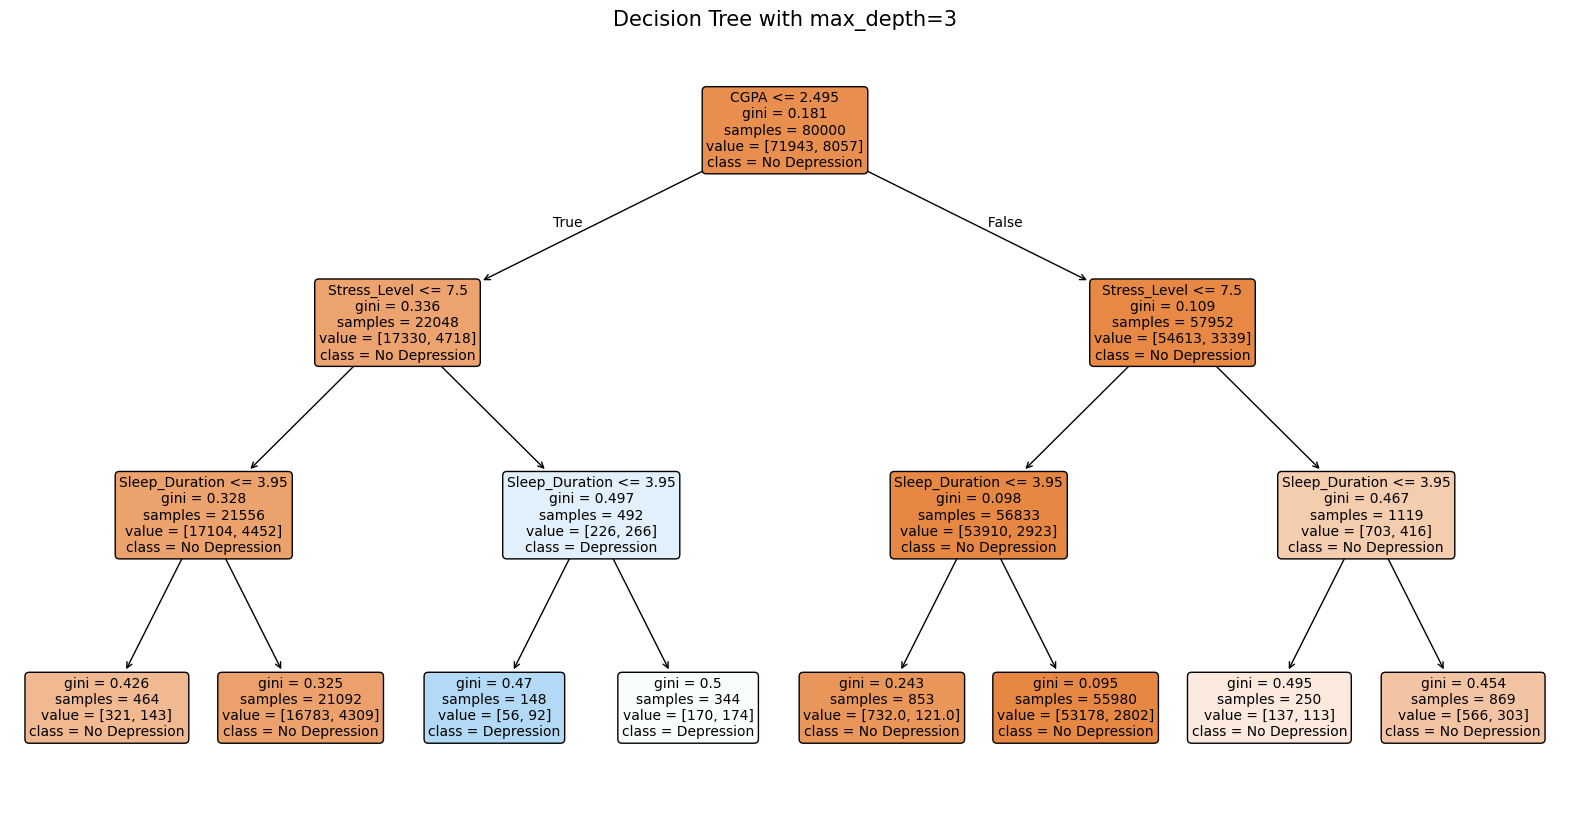

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Instantiate a DecisionTreeClassifier with max_depth=3 and random_state=42
dt_max_depth_3 = DecisionTreeClassifier(max_depth=3, random_state=42)

# Fit the classifier to the training data
print("Training Decision Tree Classifier with max_depth=3...")
dt_max_depth_3.fit(X_train, y_train)
print("Decision Tree Classifier trained successfully.")

# Visualize the trained decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_max_depth_3,
          feature_names=X_train.columns.tolist(),
          class_names=['No Depression', 'Depression'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree with max_depth=3', fontsize=15)
plt.show()


A decision tree with `max_depth=3` is significantly simpler and more interpretable than a deeper tree.

 With only three levels of decisions, it's easy to follow the paths from the root node to the leaf nodes and understand the specific rules the model uses to classify a sample.

 This limited depth prevents the tree from becoming overly complex and overfitting the training data, making its logic transparent and easy for humans to comprehend.

 Each split in the tree represents a clear decision based on a single feature, contributing to its high interpretability.

 However, this simplicity might come at the cost of lower predictive accuracy, as it may not capture all the nuances and complex relationships present in the data.

Depth of 5

Training Decision Tree Classifier with max_depth=5...
Decision Tree Classifier trained successfully.


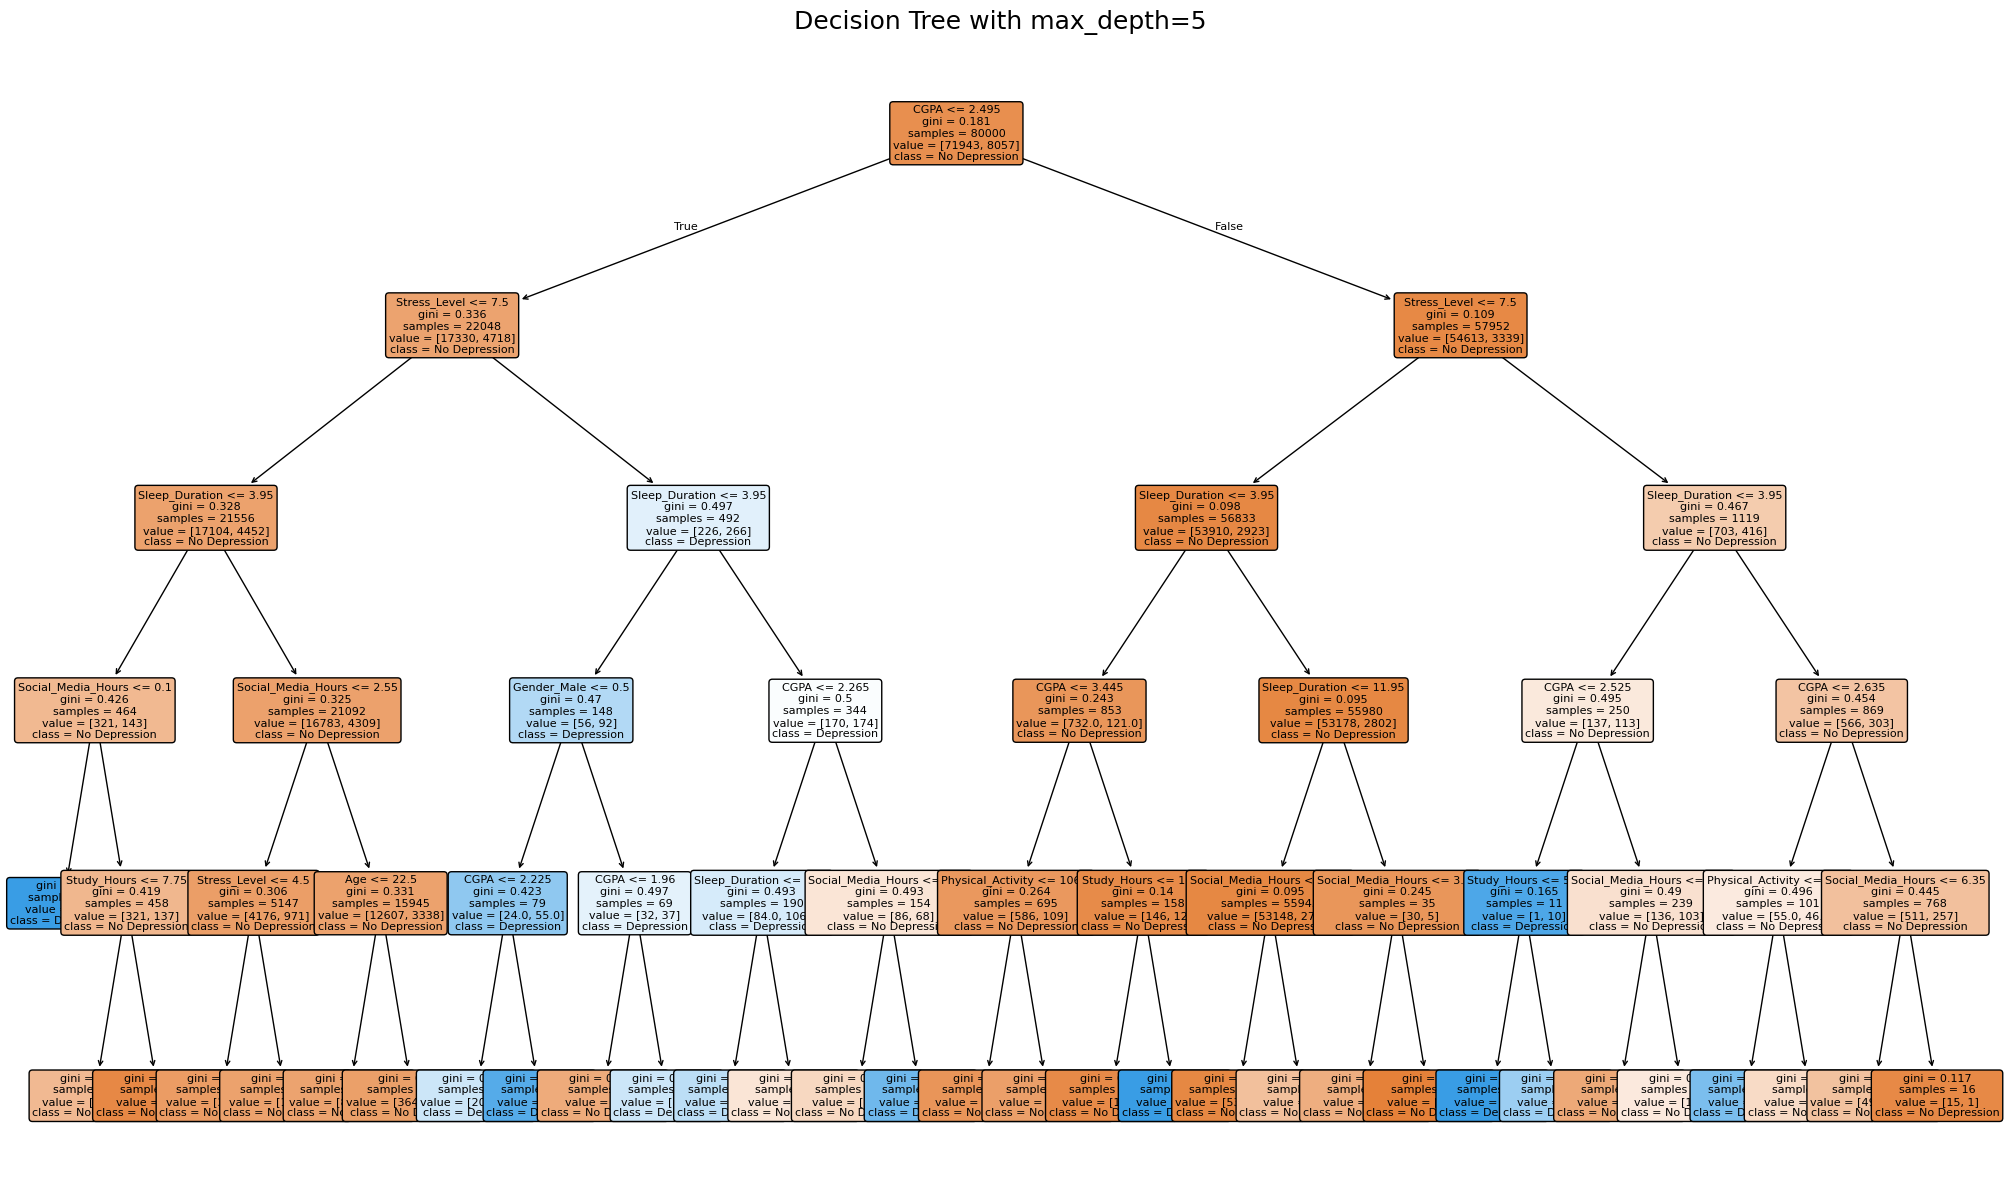

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Instantiate a DecisionTreeClassifier with max_depth=5 and random_state=42
dt_max_depth_5 = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Fit the classifier to the training data
print("Training Decision Tree Classifier with max_depth=5...")
dt_max_depth_5.fit(X_train, y_train)
print("Decision Tree Classifier trained successfully.")

# 3. Visualize the trained decision tree
plt.figure(figsize=(25, 15))
plot_tree(dt_max_depth_5,
          feature_names=X_train.columns.tolist(),
          class_names=['No Depression', 'Depression'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree with max_depth=5', fontsize=18)
plt.show()


A decision tree with `max_depth=5` is more complex and deeper than the tree with `max_depth=3`. It has more decision nodes and leaf nodes, allowing it to capture more intricate patterns in the data.

The additional two levels of depth mean that the decision paths from the root to the leaf nodes are longer, involving more sequential conditions. This increased complexity can lead to a more accurate model, as it can differentiate between classes with finer granularity.

However, it also makes the tree less interpretable compared to the `max_depth=3` tree, as following the decision logic becomes more challenging.

The `max_depth=5` tree delves deeper into the feature space, potentially leading to a better fit for the training data but also increasing the risk of overfitting.

Depth of 10

Training Decision Tree Classifier with max_depth=10 and min_samples_leaf=10...
Decision Tree Classifier trained successfully.


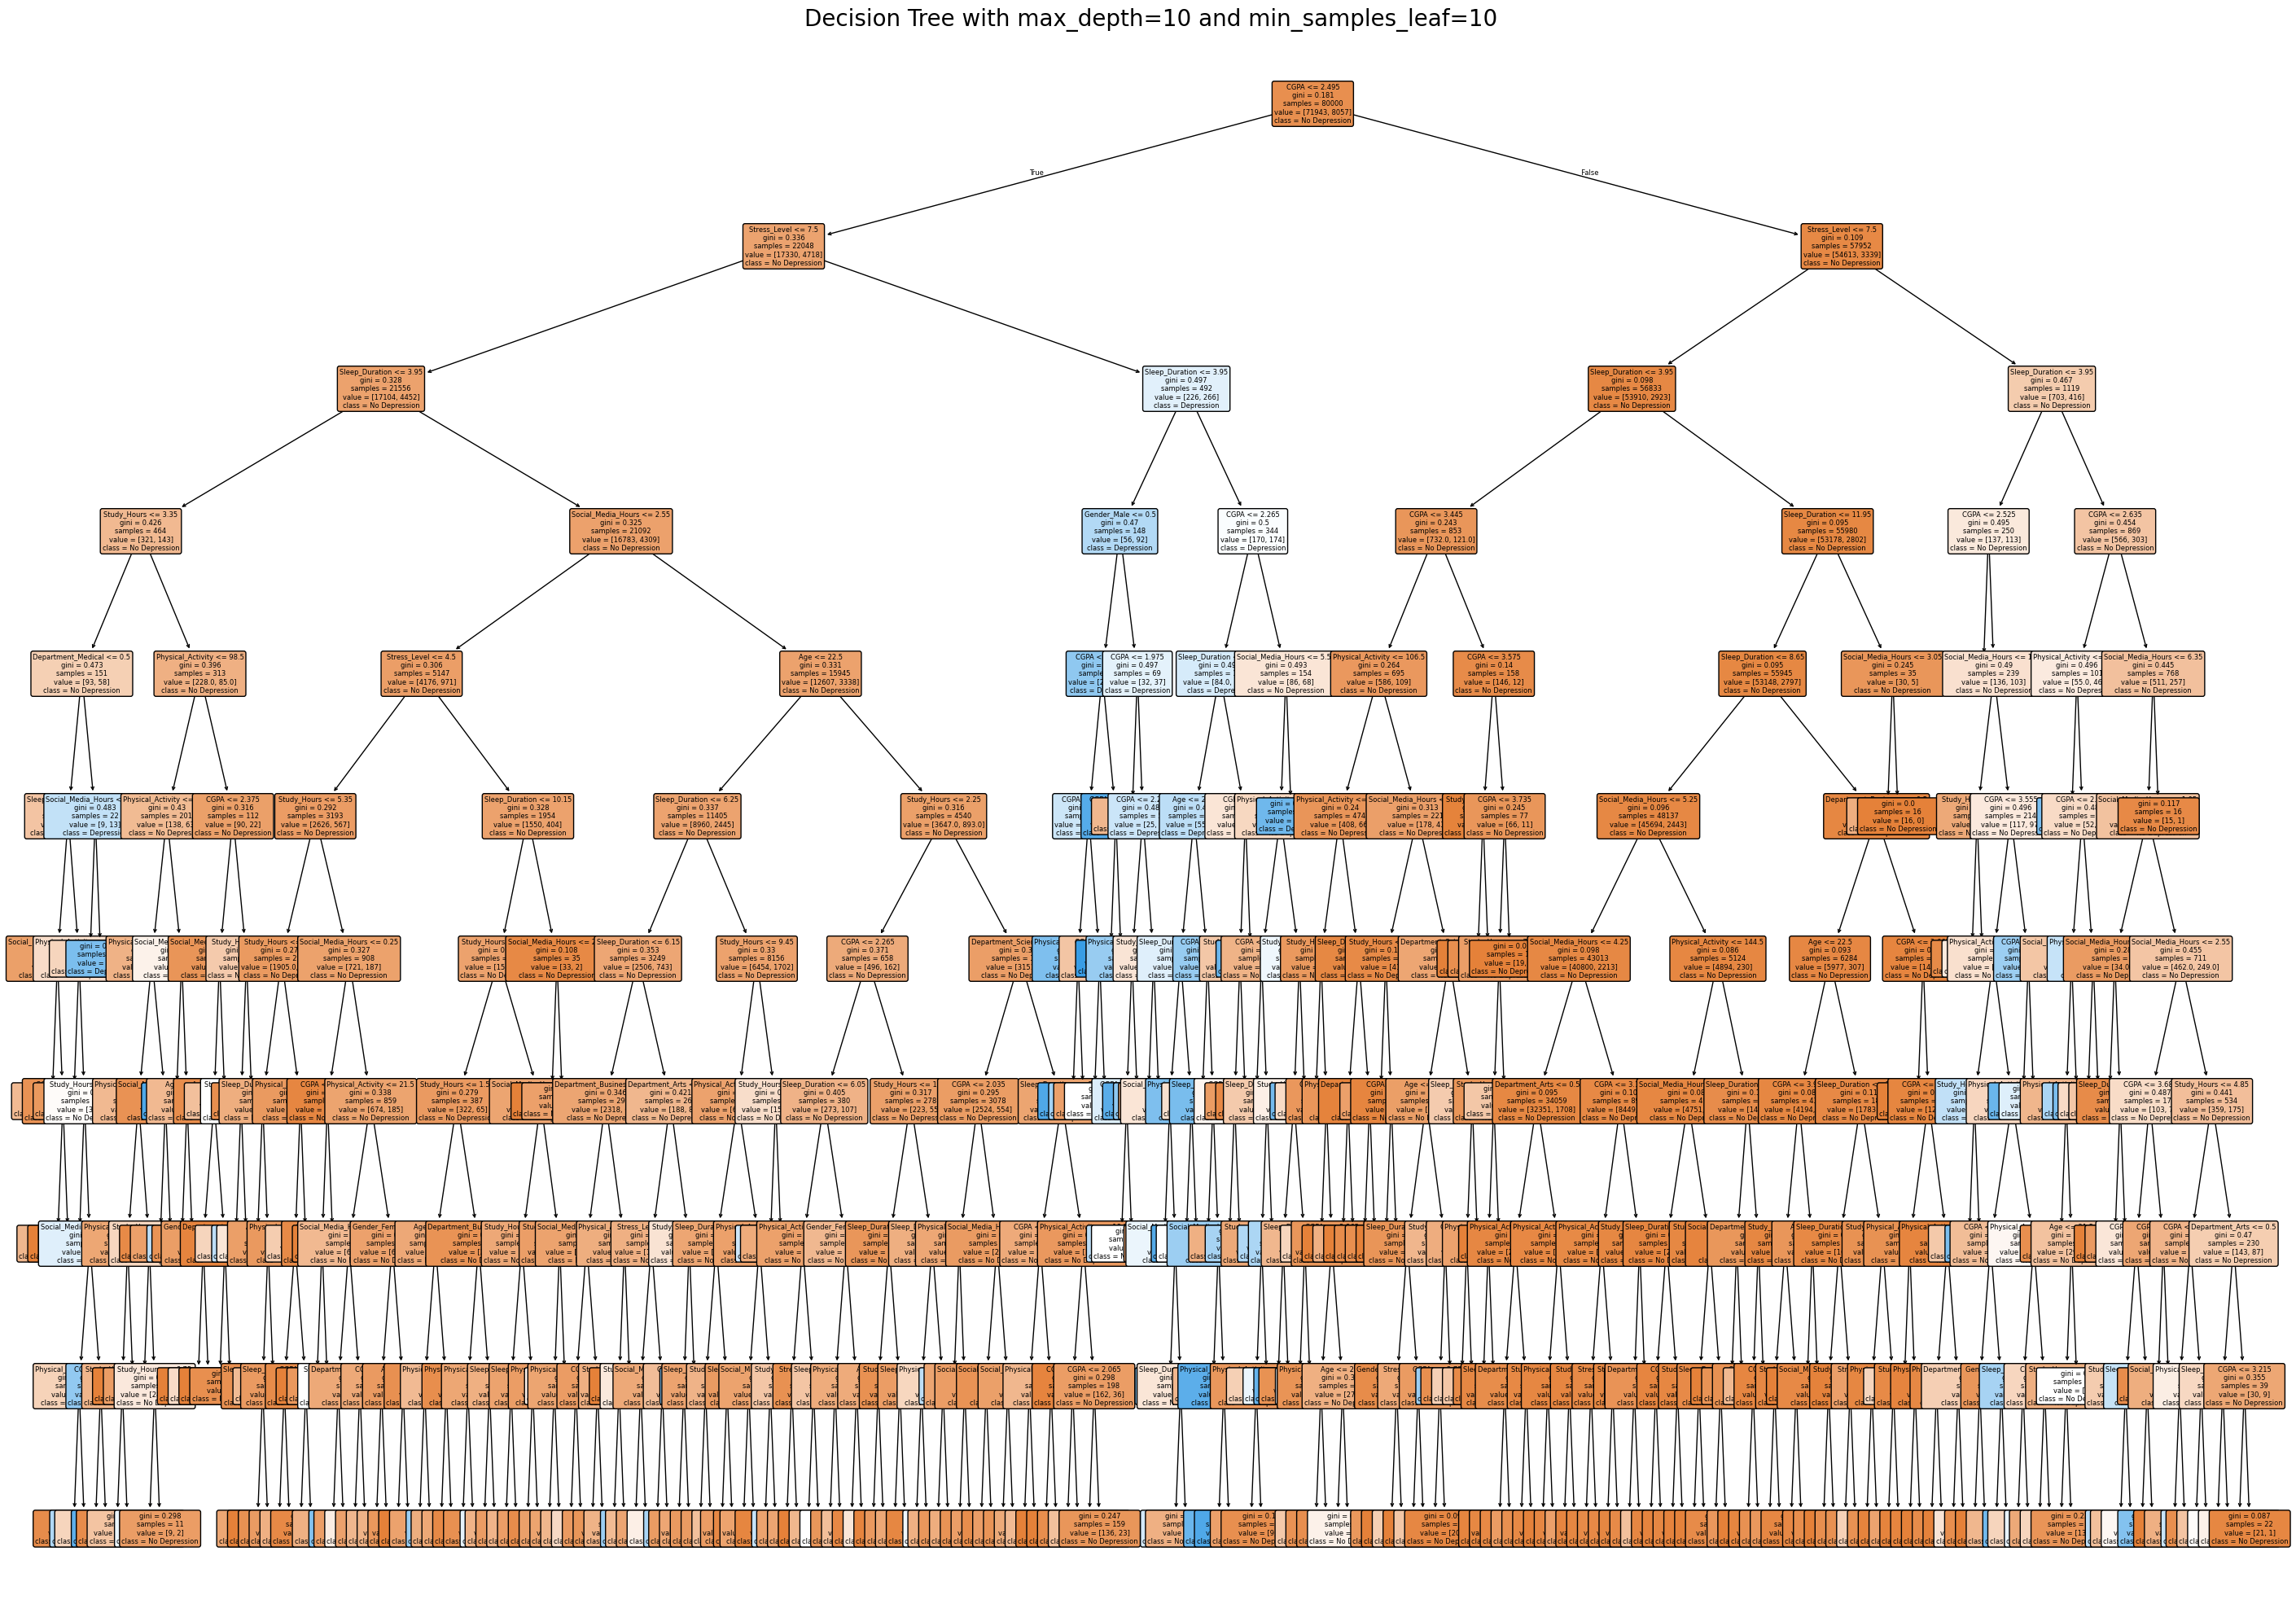

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Instantiate a DecisionTreeClassifier with max_depth=10 and min_samples_leaf=10
dt_max_depth_10_min_samples_leaf_10 = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, random_state=42)

# Fit the classifier to the training data
print("Training Decision Tree Classifier with max_depth=10 and min_samples_leaf=10...")
dt_max_depth_10_min_samples_leaf_10.fit(X_train, y_train)
print("Decision Tree Classifier trained successfully.")

# Visualize the trained decision tree
plt.figure(figsize=(35, 25))
plot_tree(dt_max_depth_10_min_samples_leaf_10,
          feature_names=X_train.columns.tolist(),
          class_names=['No Depression', 'Depression'],
          filled=True,
          rounded=True,
          fontsize=6)
plt.title('Decision Tree with max_depth=10 and min_samples_leaf=10', fontsize=20)
plt.show()


A decision tree trained with `max_depth=10` is significantly deeper and more complex than the trees with `max_depth=3` and `max_depth=5`. This increased depth allows the tree to capture a greater number of patterns and interactions within the data, potentially leading to higher accuracy on the training set. However, a deeper tree also means longer and more numerous decision paths, which makes it considerably harder to interpret and understand the logic behind its predictions. The complexity increases substantially, as there are many more nodes and splits to consider.

The `min_samples_leaf=10` parameter, on the other hand, acts as a regularization technique. While `max_depth=10` encourages deeper growth, `min_samples_leaf=10` ensures that each leaf node must contain at least 10 samples. This constraint helps to prune the tree and prevent it from creating leaf nodes that are too specific to a very small number of training examples, thereby reducing the risk of overfitting. Without `min_samples_leaf` (or with a very small value like 1), a `max_depth=10` tree could easily overfit by creating highly specialized rules for individual data points. By setting it to 10, the tree is forced to generalize a bit more at its terminal nodes, balancing the complexity allowed by `max_depth` with a mechanism to reduce overfitting compared to a fully grown, unconstrained tree.

Compared to `max_depth=3` and `max_depth=5` trees, this `max_depth=10` with `min_samples_leaf=10` tree is much more complex and likely to achieve higher training accuracy but with a greater risk of overfitting to the training data. The `min_samples_leaf` helps mitigate this risk to some extent by ensuring a minimum number of samples in each leaf, which is a good practice when allowing for deeper trees.

##Sensitivity analysis

Sensitivity analysis shows how different values of an independent variable affect a dependent variable under a given set of assumptions. Companies use sensitivity analysis to identify opportunities, mitigate risk, and communicate decisions to upper management.

how target variables are affected based on changes in input variables. By creating a given set of variables, an analyst can determine how changes in one variable affect the outcome.

Sensitivity analysis enables forecasting based on historical, true data. By studying all the variables and the possible outcomes, decisions can be made about business activities and investing decisions,

Performing a sensitivity analysis typically follows a structured sequence:

Define the Baseline Scenario: Establish your "business as usual" model using the most likely or current data. This serves as the benchmark for comparison.

Identify Key Variables: Determine which input variables are the most uncertain or impactful (e.g., interest rates, material costs, or customer demand).

Establish Ranges: Decide on the range of variation for each variable (e.g., "what if the price of gas increases by 10%, 20%, or 50%?").

Execute the Analysis: Adjust the variables using specific methods (detailed below) and record the changes in the output (e.g., total profit or project timeline).

Analyze and Visualize: Evaluate the results to see which variables cause the most significant swings in the outcome. Common visual tools include Tornado Charts (which rank variables by impact) and Spider Charts.

Citations:

https://www.investopedia.com/terms/s/sensitivityanalysis.asp

Rose E. (2025). Sensitivity Analysis. The Decision Lab. Retrieved January 31, 2026, from https://thedecisionlab.com/reference-guide/statistics/sensitivity-analysis

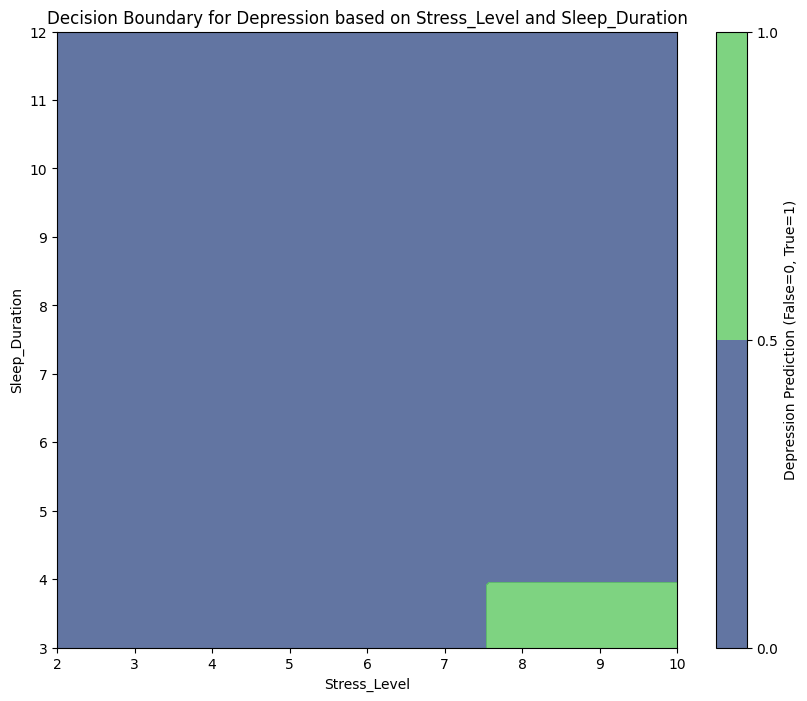

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Select the two relevant input features
feature1_name = 'Stress_Level'
feature2_name = 'Sleep_Duration'

# 2. Create a base feature vector by taking the mean of all features in X_train,
# excluding the two features chosen for sensitivity analysis.
base_features = X_train.drop(columns=[feature1_name, feature2_name]).mean()

# Handle boolean columns: convert their mean to the nearest integer (0 or 1)
# Identify boolean columns from the original df_encoded for proper rounding
boolean_cols = X_train.select_dtypes(include='bool').columns
for col in boolean_cols:
    if col in base_features.index:
        base_features[col] = round(base_features[col])

# 3. Define a range of values for Stress_Level and Sleep_Duration
# Get min and max from the original full dataset (df_encoded) to cover the full range
stress_min, stress_max = df_encoded[feature1_name].min(), df_encoded[feature1_name].max()
sleep_min, sleep_max = df_encoded[feature2_name].min(), df_encoded[feature2_name].max()

stress_range = np.linspace(stress_min, stress_max, 100)
sleep_range = np.linspace(sleep_min, sleep_max, 100)

# 4. Use np.meshgrid to create 2D arrays
X_grid, Y_grid = np.meshgrid(stress_range, sleep_range)

# 5. Create a DataFrame for predictions (prediction_data)
# This DataFrame should have the same columns as X_train.
prediction_data = pd.DataFrame(columns=X_train.columns)

# Fill all other columns with the constant values from the base feature vector
for col in base_features.index:
    prediction_data[col] = base_features[col]

# Populate the columns corresponding to the two varying features with X_grid and Y_grid (flattened)
prediction_data[feature1_name] = X_grid.ravel()
prediction_data[feature2_name] = Y_grid.ravel()

# Ensure column order matches X_train for prediction
prediction_data = prediction_data[X_train.columns]

# 6. Use the trained Decision Tree model to predict the 'Depression' outcomes
Z = dt_max_depth_10_min_samples_leaf_10.predict(prediction_data)

# 7. Reshape the predictions Z to match the shape of the meshgrid
Z = Z.reshape(X_grid.shape)

# 8. Create a contour plot
plt.figure(figsize=(10, 8))
plt.contourf(X_grid, Y_grid, Z, alpha=0.8, cmap='viridis')
plt.colorbar(label='Depression Prediction (False=0, True=1)')

# 9. Add labels and title
plt.xlabel(feature1_name)
plt.ylabel(feature2_name)
plt.title(f'Decision Boundary for Depression based on {feature1_name} and {feature2_name}')

# 10. Display the plot
plt.show()


##What does this decision boundary mean to sensitivity analysis
In this decision boundary plot we can visiualize he Decision Tree Classifier based off `Stress_Level` and `Sleep_Duration`. Whichs shows us how the model predicts Drepression for various combinations of these two features

 The different colored regions on the plot represent the model's predicted class (`Depression` or `No Depression`).


   

By observing the shapes and locations of the colored regions, we can understand how changes in `Stress_Level` and `Sleep_Duration` influence the model's prediction. For example, if higher `Stress_Level` and lower `Sleep_Duration` tend to fall into the 'Depression' region, it suggests these factors are strong indicators according to the model.

The boundaries reflect the rules and splits made by `dt_max_depth_10_min_samples_leaf_10` model. Since a Decision Tree makes axis-parallel splits, you'll see rectangular or staircase-like regions, indicating that the model makes decisions based on simple thresholds for each feature.


#Task 2

##Stratified K-Fold Cross Validation
Provides train/test indices to split data in train/test sets.

This cross-validation object is a variation of KFold that returns stratified folds. The folds are made by preserving the percentage of samples for each class in y in a binary or multiclass classification setting.

In stratified K-fold cross-validation, each fold acts as a distinct, balanced subset of the data, created by partitioning the dataset into \(K\) parts while preserving the original percentage of samples for each class. This ensures that every fold is a representative mini-dataset, preventing biased evaluation, especially with imbalanced datasets.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html

##Bagging Algorithm (Random Forest) with Stratified K-Fold



In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [19]:
n_splits_values = [5, 10, 15]
rf_results = {}

for n_splits in n_splits_values:
    print(f"\n--- Evaluating RandomForestClassifier with {n_splits} folds ---")
    fold_accuracies = []
    fold_precisions = []
    fold_f1_scores = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    rf_classifier = RandomForestClassifier(random_state=42)

    for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        rf_classifier.fit(X_train_fold, y_train_fold)
        y_pred_fold = rf_classifier.predict(X_test_fold)

        fold_accuracies.append(accuracy_score(y_test_fold, y_pred_fold))
        fold_precisions.append(precision_score(y_test_fold, y_pred_fold))
        fold_f1_scores.append(f1_score(y_test_fold, y_pred_fold))
        print(f"  Fold {fold+1} - Accuracy: {fold_accuracies[-1]:.4f}, Precision: {fold_precisions[-1]:.4f}, F1-Score: {fold_f1_scores[-1]:.4f}")

    avg_accuracy = np.mean(fold_accuracies)
    avg_precision = np.mean(fold_precisions)
    avg_f1_score = np.mean(fold_f1_scores)

    rf_results[f'{n_splits}_folds'] = {
        'accuracy': avg_accuracy,
        'precision': avg_precision,
        'f1_score': avg_f1_score
    }
    print(f"Average Metrics for {n_splits} folds: Accuracy={avg_accuracy:.4f}, Precision={avg_precision:.4f}, F1-Score={avg_f1_score:.4f}")

print("\nRandom Forest Classifier Results:")
for key, value in rf_results.items():
    print(f"{key}: Accuracy={value['accuracy']:.4f}, Precision={value['precision']:.4f}, F1-Score={value['f1_score']:.4f}")


--- Evaluating RandomForestClassifier with 5 folds ---
  Fold 1 - Accuracy: 0.8997, Precision: 0.5357, F1-Score: 0.0429
  Fold 2 - Accuracy: 0.8991, Precision: 0.4557, F1-Score: 0.0344
  Fold 3 - Accuracy: 0.8991, Precision: 0.4659, F1-Score: 0.0390
  Fold 4 - Accuracy: 0.8989, Precision: 0.4444, F1-Score: 0.0380
  Fold 5 - Accuracy: 0.8992, Precision: 0.4815, F1-Score: 0.0372
Average Metrics for 5 folds: Accuracy=0.8992, Precision=0.4766, F1-Score=0.0383

--- Evaluating RandomForestClassifier with 10 folds ---
  Fold 1 - Accuracy: 0.8994, Precision: 0.5000, F1-Score: 0.0491
  Fold 2 - Accuracy: 0.8995, Precision: 0.5122, F1-Score: 0.0401
  Fold 3 - Accuracy: 0.8992, Precision: 0.4815, F1-Score: 0.0491
  Fold 4 - Accuracy: 0.8993, Precision: 0.4878, F1-Score: 0.0382
  Fold 5 - Accuracy: 0.9002, Precision: 0.6250, F1-Score: 0.0385
  Fold 6 - Accuracy: 0.8982, Precision: 0.3750, F1-Score: 0.0342
  Fold 7 - Accuracy: 0.8993, Precision: 0.4906, F1-Score: 0.0491
  Fold 8 - Accuracy: 0.8991

###Behavior  of Baggig Algorithms metrics
The `accuracy` on average is shown to be pretty stable and pretty high between 5,10,15 k folds, it highlights that model is good at predicting the majority class.

The `precision` is very moderate fluctuating on average between 47% and 49% while some folds showhigh precision, revealing that there is instability in minority class prediction that is not revealed in the accuracy

The `F1 Scores` are low throughout thefolds which implies a poor recall for positive class.

Through these metrics we can be shown that the dataset is very imbalanced implied by the high accuracy and low F1 scores, where F1 scores applies penalties to Low recall and failure to correctly identify the minority class. Each metrics helps identify and emphaisze different aspects of the models behavior because if we just used Accuracy we would think the model is high-performing but exploring the precision and F1 Score we notice that is low-performing in these areas

##Boosting Algorithm (Gradient Boosting) with Stratified K-Fold


In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np

print("Required libraries for Gradient Boosting imported successfully.")

Required libraries for Gradient Boosting imported successfully.


In [21]:
n_splits_values = [5, 10, 15]
gb_results = {}

for n_splits in n_splits_values:
    print(f"\n--- Evaluating GradientBoostingClassifier with {n_splits} folds ---")
    fold_accuracies = []
    fold_precisions = []
    fold_f1_scores = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    gb_classifier = GradientBoostingClassifier(random_state=42)

    for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

        gb_classifier.fit(X_train_fold, y_train_fold)
        y_pred_fold = gb_classifier.predict(X_test_fold)

        fold_accuracies.append(accuracy_score(y_test_fold, y_pred_fold))
        fold_precisions.append(precision_score(y_test_fold, y_pred_fold))
        fold_f1_scores.append(f1_score(y_test_fold, y_pred_fold))
        print(f"  Fold {fold+1} - Accuracy: {fold_accuracies[-1]:.4f}, Precision: {fold_precisions[-1]:.4f}, F1-Score: {fold_f1_scores[-1]:.4f}")

    avg_accuracy = np.mean(fold_accuracies)
    avg_precision = np.mean(fold_precisions)
    avg_f1_score = np.mean(fold_f1_scores)

    gb_results[f'{n_splits}_folds'] = {
        'accuracy': avg_accuracy,
        'precision': avg_precision,
        'f1_score': avg_f1_score
    }
    print(f"Average Metrics for {n_splits} folds: Accuracy={avg_accuracy:.4f}, Precision={avg_precision:.4f}, F1-Score={avg_f1_score:.4f}")

print("\nGradient Boosting Classifier Results:")
for key, value in gb_results.items():
    print(f"{key}: Accuracy={value['accuracy']:.4f}, Precision={value['precision']:.4f}, F1-Score={value['f1_score']:.4f}")


--- Evaluating GradientBoostingClassifier with 5 folds ---
  Fold 1 - Accuracy: 0.8994, Precision: 0.5000, F1-Score: 0.0336
  Fold 2 - Accuracy: 0.8995, Precision: 0.5185, F1-Score: 0.0401
  Fold 3 - Accuracy: 0.8995, Precision: 0.5155, F1-Score: 0.0474
  Fold 4 - Accuracy: 0.8993, Precision: 0.4937, F1-Score: 0.0373
  Fold 5 - Accuracy: 0.8998, Precision: 0.5616, F1-Score: 0.0393
Average Metrics for 5 folds: Accuracy=0.8995, Precision=0.5179, F1-Score=0.0396

--- Evaluating GradientBoostingClassifier with 10 folds ---
  Fold 1 - Accuracy: 0.8987, Precision: 0.3871, F1-Score: 0.0231
  Fold 2 - Accuracy: 0.9006, Precision: 0.6667, F1-Score: 0.0461
  Fold 3 - Accuracy: 0.8994, Precision: 0.5000, F1-Score: 0.0327
  Fold 4 - Accuracy: 0.8993, Precision: 0.4872, F1-Score: 0.0364
  Fold 5 - Accuracy: 0.9002, Precision: 0.6333, F1-Score: 0.0367
  Fold 6 - Accuracy: 0.8979, Precision: 0.3636, F1-Score: 0.0377
  Fold 7 - Accuracy: 0.8993, Precision: 0.4857, F1-Score: 0.0327
  Fold 8 - Accuracy

###Behavior of Boosting Algorithim

Similar to our Bagging Algorithm
The `accuracy` is reaching the same near average abut 89.9% accuracy across all the folds and is unaffected, which if we just look at accuracy we would assume the algorithm is strong

The `Precision` achieves slighlty higher precision than the random forest which shows improvement and means it better at avoiding false positives when it predicts the positive class compared to the Random Forest Cassification

The `F1 score`is about the same in gradient bosting and still does not handle the minority class well

So when we compare the ranking
* `Accuracy` is about the same and none performs better
* `Precision` Gradient Boosting is preferred
* `F1 Score` is slightly better

# Task 3

##Confsion Matrix


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Instantiate classifiers with random_state=42
dt_classifier = DecisionTreeClassifier(random_state=42)
rf_classifier_cm = RandomForestClassifier(random_state=42)
gb_classifier_cm = GradientBoostingClassifier(random_state=42)

print("Instantiated DecisionTreeClassifier, RandomForestClassifier, and GradientBoostingClassifier.")

# Train each classifier
print("\nTraining DecisionTreeClassifier...")
dt_classifier.fit(X_train, y_train)
print("DecisionTreeClassifier trained.")

print("\nTraining RandomForestClassifier...")
rf_classifier_cm.fit(X_train, y_train)
print("RandomForestClassifier trained.")

print("\nTraining GradientBoostingClassifier...")
gb_classifier_cm.fit(X_train, y_train)
print("GradientBoostingClassifier trained.")

Instantiated DecisionTreeClassifier, RandomForestClassifier, and GradientBoostingClassifier.

Training DecisionTreeClassifier...
DecisionTreeClassifier trained.

Training RandomForestClassifier...
RandomForestClassifier trained.

Training GradientBoostingClassifier...
GradientBoostingClassifier trained.


Generating Confusion Matrix for RandomForestClassifier...


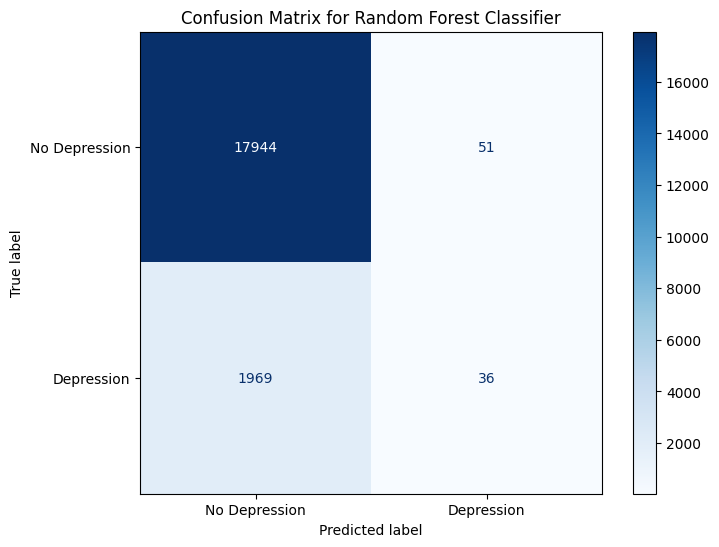

Confusion Matrix for RandomForestClassifier displayed.


In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set using the retrained RandomForestClassifier
y_pred_rf_cm = rf_classifier_cm.predict(X_test)

# Generate and visualize the confusion matrix for RandomForestClassifier
print("Generating Confusion Matrix for RandomForestClassifier...")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    rf_classifier_cm, X_test, y_test, cmap=plt.cm.Blues, ax=ax,
    display_labels=['No Depression', 'Depression']
)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()
print("Confusion Matrix for RandomForestClassifier displayed.")

In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np

# Define the number of splits for StratifiedKFold
num_folds = 10
skf_dt = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialize lists to store metrics for each fold
fold_accuracies_dt = []
fold_precisions_dt = []
fold_f1_scores_dt = []

print(f"Evaluating Decision Tree Classifier with {num_folds}-fold Stratified K-Fold Cross Validation...")

# Loop through each fold
for fold, (train_index, test_index) in enumerate(skf_dt.split(X, y)):
    X_train_fold_dt, X_test_fold_dt = X.iloc[train_index], X.iloc[test_index]
    y_train_fold_dt, y_test_fold_dt = y.iloc[train_index], y.iloc[test_index]

    # Re-train the Decision Tree Classifier for each fold
    # (A new instance is created to avoid data leakage from previous folds)
    dt_classifier_fold = DecisionTreeClassifier(random_state=42)
    dt_classifier_fold.fit(X_train_fold_dt, y_train_fold_dt)

    # Make predictions
    y_pred_fold_dt = dt_classifier_fold.predict(X_test_fold_dt)

    # Calculate metrics and store them
    fold_accuracies_dt.append(accuracy_score(y_test_fold_dt, y_pred_fold_dt))
    fold_precisions_dt.append(precision_score(y_test_fold_dt, y_pred_fold_dt, zero_division=0))
    fold_f1_scores_dt.append(f1_score(y_test_fold_dt, y_pred_fold_dt, zero_division=0))

    print(f"  Fold {fold + 1}/{num_folds} - Accuracy: {fold_accuracies_dt[-1]:.4f}, Precision: {fold_precisions_dt[-1]:.4f}, F1-Score: {fold_f1_scores_dt[-1]:.4f}")

# Calculate and print average metrics
avg_accuracy_dt = np.mean(fold_accuracies_dt)
avg_precision_dt = np.mean(fold_precisions_dt)
avg_f1_score_dt = np.mean(fold_f1_scores_dt)

print(f"\nAverage Metrics for Decision Tree Classifier over {num_folds} folds:")
print(f"  Accuracy:  {avg_accuracy_dt:.4f}")
print(f"  Precision: {avg_precision_dt:.4f}")
print(f"  F1-Score:  {avg_f1_score_dt:.4f}")


Evaluating Decision Tree Classifier with 10-fold Stratified K-Fold Cross Validation...
  Fold 1/10 - Accuracy: 0.8203, Precision: 0.1657, F1-Score: 0.1791
  Fold 2/10 - Accuracy: 0.8110, Precision: 0.1359, F1-Score: 0.1486
  Fold 3/10 - Accuracy: 0.8164, Precision: 0.1489, F1-Score: 0.1609
  Fold 4/10 - Accuracy: 0.8131, Precision: 0.1401, F1-Score: 0.1524
  Fold 5/10 - Accuracy: 0.8211, Precision: 0.1538, F1-Score: 0.1628
  Fold 6/10 - Accuracy: 0.8159, Precision: 0.1518, F1-Score: 0.1651
  Fold 7/10 - Accuracy: 0.8158, Precision: 0.1557, F1-Score: 0.1703
  Fold 8/10 - Accuracy: 0.8156, Precision: 0.1577, F1-Score: 0.1731
  Fold 9/10 - Accuracy: 0.8177, Precision: 0.1678, F1-Score: 0.1843
  Fold 10/10 - Accuracy: 0.8199, Precision: 0.1613, F1-Score: 0.1735

Average Metrics for Decision Tree Classifier over 10 folds:
  Accuracy:  0.8167
  Precision: 0.1539
  F1-Score:  0.1670


To perform paired t-tests, we need the F1-scores for each fold for all three models.



In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np

# Define the number of splits for StratifiedKFold
num_folds = 10
skf_rf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialize lists to store metrics for each fold for Random Forest
fold_accuracies_rf = []
fold_precisions_rf = []
fold_f1_scores_rf = []

print(f"Evaluating Random Forest Classifier with {num_folds}-fold Stratified K-Fold Cross Validation...")

# Loop through each fold
for fold, (train_index, test_index) in enumerate(skf_rf.split(X, y)):
    X_train_fold_rf, X_test_fold_rf = X.iloc[train_index], X.iloc[test_index]
    y_train_fold_rf, y_test_fold_rf = y.iloc[train_index], y.iloc[test_index]

    # Re-train the Random Forest Classifier for each fold
    rf_classifier_fold = RandomForestClassifier(random_state=42)
    rf_classifier_fold.fit(X_train_fold_rf, y_train_fold_rf)

    # Make predictions
    y_pred_fold_rf = rf_classifier_fold.predict(X_test_fold_rf)

    # Calculate metrics and store them
    fold_accuracies_rf.append(accuracy_score(y_test_fold_rf, y_pred_fold_rf))
    fold_precisions_rf.append(precision_score(y_test_fold_rf, y_pred_fold_rf, zero_division=0))
    fold_f1_scores_rf.append(f1_score(y_test_fold_rf, y_pred_fold_rf, zero_division=0))

    print(f"  Fold {fold + 1}/{num_folds} - Accuracy: {fold_accuracies_rf[-1]:.4f}, Precision: {fold_precisions_rf[-1]:.4f}, F1-Score: {fold_f1_scores_rf[-1]:.4f}")

# Calculate and print average metrics
avg_accuracy_rf = np.mean(fold_accuracies_rf)
avg_precision_rf = np.mean(fold_precisions_rf)
avg_f1_score_rf = np.mean(fold_f1_scores_rf)

print(f"\nAverage Metrics for Random Forest Classifier over {num_folds} folds:")
print(f"  Accuracy:  {avg_accuracy_rf:.4f}")
print(f"  Precision: {avg_precision_rf:.4f}")
print(f"  F1-Score:  {avg_f1_score_rf:.4f}")

Evaluating Random Forest Classifier with 10-fold Stratified K-Fold Cross Validation...
  Fold 1/10 - Accuracy: 0.8994, Precision: 0.5000, F1-Score: 0.0491
  Fold 2/10 - Accuracy: 0.8995, Precision: 0.5122, F1-Score: 0.0401
  Fold 3/10 - Accuracy: 0.8992, Precision: 0.4815, F1-Score: 0.0491
  Fold 4/10 - Accuracy: 0.8993, Precision: 0.4878, F1-Score: 0.0382
  Fold 5/10 - Accuracy: 0.9002, Precision: 0.6250, F1-Score: 0.0385
  Fold 6/10 - Accuracy: 0.8982, Precision: 0.3750, F1-Score: 0.0342
  Fold 7/10 - Accuracy: 0.8993, Precision: 0.4906, F1-Score: 0.0491
  Fold 8/10 - Accuracy: 0.8991, Precision: 0.4694, F1-Score: 0.0436
  Fold 9/10 - Accuracy: 0.8983, Precision: 0.3864, F1-Score: 0.0324
  Fold 10/10 - Accuracy: 0.9000, Precision: 0.5814, F1-Score: 0.0476

Average Metrics for Random Forest Classifier over 10 folds:
  Accuracy:  0.8993
  Precision: 0.4909
  F1-Score:  0.0422


Calculate the fold-wise accuracy, precision, and F1-scores for the Gradient Boosting Classifier using 10-fold Stratified K-Fold cross-validation.



In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np

# Define the number of splits for StratifiedKFold
num_folds = 10
skf_gb = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialize lists to store metrics for each fold for Gradient Boosting
fold_accuracies_gb = []
fold_precisions_gb = []
fold_f1_scores_gb = []

print(f"Evaluating Gradient Boosting Classifier with {num_folds}-fold Stratified K-Fold Cross Validation...")

# Loop through each fold
for fold, (train_index, test_index) in enumerate(skf_gb.split(X, y)):
    X_train_fold_gb, X_test_fold_gb = X.iloc[train_index], X.iloc[test_index]
    y_train_fold_gb, y_test_fold_gb = y.iloc[train_index], y.iloc[test_index]

    # Re-train the Gradient Boosting Classifier for each fold
    gb_classifier_fold = GradientBoostingClassifier(random_state=42)
    gb_classifier_fold.fit(X_train_fold_gb, y_train_fold_gb)

    # Make predictions
    y_pred_fold_gb = gb_classifier_fold.predict(X_test_fold_gb)

    # Calculate metrics and store them
    fold_accuracies_gb.append(accuracy_score(y_test_fold_gb, y_pred_fold_gb))
    fold_precisions_gb.append(precision_score(y_test_fold_gb, y_pred_fold_gb, zero_division=0))
    fold_f1_scores_gb.append(f1_score(y_test_fold_gb, y_pred_fold_gb, zero_division=0))

    print(f"  Fold {fold + 1}/{num_folds} - Accuracy: {fold_accuracies_gb[-1]:.4f}, Precision: {fold_precisions_gb[-1]:.4f}, F1-Score: {fold_f1_scores_gb[-1]:.4f}")

# Calculate and print average metrics
avg_accuracy_gb = np.mean(fold_accuracies_gb)
avg_precision_gb = np.mean(fold_precisions_gb)
avg_f1_score_gb = np.mean(fold_f1_scores_gb)

print(f"\nAverage Metrics for Gradient Boosting Classifier over {num_folds} folds:")
print(f"  Accuracy:  {avg_accuracy_gb:.4f}")
print(f"  Precision: {avg_precision_gb:.4f}")
print(f"  F1-Score:  {avg_f1_score_gb:.4f}")

Evaluating Gradient Boosting Classifier with 10-fold Stratified K-Fold Cross Validation...
  Fold 1/10 - Accuracy: 0.8987, Precision: 0.3871, F1-Score: 0.0231
  Fold 2/10 - Accuracy: 0.9006, Precision: 0.6667, F1-Score: 0.0461
  Fold 3/10 - Accuracy: 0.8994, Precision: 0.5000, F1-Score: 0.0327
  Fold 4/10 - Accuracy: 0.8993, Precision: 0.4872, F1-Score: 0.0364
  Fold 5/10 - Accuracy: 0.9002, Precision: 0.6333, F1-Score: 0.0367
  Fold 6/10 - Accuracy: 0.8979, Precision: 0.3636, F1-Score: 0.0377
  Fold 7/10 - Accuracy: 0.8993, Precision: 0.4857, F1-Score: 0.0327
  Fold 8/10 - Accuracy: 0.8995, Precision: 0.5135, F1-Score: 0.0364
  Fold 9/10 - Accuracy: 0.8993, Precision: 0.5000, F1-Score: 0.0289
  Fold 10/10 - Accuracy: 0.8997, Precision: 0.5435, F1-Score: 0.0475

Average Metrics for Gradient Boosting Classifier over 10 folds:
  Accuracy:  0.8994
  Precision: 0.5081
  F1-Score:  0.0358


In [30]:
from scipy import stats

print("Performing paired t-tests on F1-scores...")

# Paired t-test: Decision Tree vs. Random Forest
t_stat_dt_rf, p_value_dt_rf = stats.ttest_rel(fold_f1_scores_dt, fold_f1_scores_rf)
print(f"\nDecision Tree vs. Random Forest (F1-score):\n  T-statistic: {t_stat_dt_rf:.4f}\n  P-value:     {p_value_dt_rf:.4f}")

# Paired t-test: Decision Tree vs. Gradient Boosting
t_stat_dt_gb, p_value_dt_gb = stats.ttest_rel(fold_f1_scores_dt, fold_f1_scores_gb)
print(f"\nDecision Tree vs. Gradient Boosting (F1-score):\n  T-statistic: {t_stat_dt_gb:.4f}\n  P-value:     {p_value_dt_gb:.4f}")

# Paired t-test: Random Forest vs. Gradient Boosting
t_stat_rf_gb, p_value_rf_gb = stats.ttest_rel(fold_f1_scores_rf, fold_f1_scores_gb)
print(f"\nRandom Forest vs. Gradient Boosting (F1-score):\n  T-statistic: {t_stat_rf_gb:.4f}\n  P-value:     {p_value_rf_gb:.4f}")



Performing paired t-tests on F1-scores...

Decision Tree vs. Random Forest (F1-score):
  T-statistic: 31.8122
  P-value:     0.0000

Decision Tree vs. Gradient Boosting (F1-score):
  T-statistic: 25.4353
  P-value:     0.0000

Random Forest vs. Gradient Boosting (F1-score):
  T-statistic: 1.9870
  P-value:     0.0782


`Decision Tree vs Random Forest` The F1 score is significantly different because the random forest underperforms on F1 because it heavily favors the majority class

`Decision Tree vs Gradient Boosting` The decision tree also performs a significantly differenlty from gradient boosting  driven by the trees lower bias and better recall of the minority class

`Random Forest vs Gradient Boosting` The difference compared to Random forest is not strong enough to rule out chance, therefore their F1 performances are statistically similar

##Bias Variance Tradeoff discussion

`Decision Tree Classifier`
* Bia: Low, A single decision tree can model very complexdecision boundaries, this low bias can be seen reflected in its ability to caputre minority- class patterns better than the ensembles
* Variance: High, since decision treees are highly sensitive to the training data, small changes in the data can lead to various tree structures. Since decision trees are Low bias but high variance there may be concerns for overfitting

`Random Forest Classifier`
* Bias: Moderate, since random forest averages many trees this helps smooth decision boundaries, which also increases bias slightly compared toa  single tree
* Variance: Low, bagging and feature randomness helps contribute to reducing the variance
Since we reduce the variance at the cost of some bias it will lead to lower F1 scores

`Gradient Boosting Classifier`
* Bias: Low, Boosting helps builds trees seuqentially which corrects previous errors
* Variance: Moderate, boosting can increase variance because later trees focus more on minority samples